# Problem Statement

In [1]:
#Build a Logistic Regression model to predict whether a tumor is Malignant or Benign using patient diagnostic measurements. 
#The Kaggle Breast Cancer Wisconsin (Diagnostic) dataset is one of the best real-world datasets to demonstrate Logistic Regression. 
#Below is a complete, clean, end-to-end ML program (lab + exam ready). 

In [2]:
#Kaggle Dataset Details 
#Dataset name (Kaggle):   Breast Cancer Wisconsin (Diagnostic) 
#Target column: 
#• diagnosis 
#o M → Malignant (1) 
#o B → Benign (0) 
#Total samples: 569 
#Features: 30 numerical features

In [3]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

In [4]:
# load kaggle Dataset
data=pd.read_csv("breast_cancer.csv")
print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [5]:
# Data preorocessing
# Drop unnecessary column 
data.drop(['id'], axis=1, inplace=True)

# Convert diagnosis to binary 
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0}) 
 
X = data.drop('diagnosis', axis=1) 
y = data['diagnosis']

In [8]:
# train-test split
X_train, X_test, y_train, y_test= train_test_split (X,y,test_size=0.25,random_state=42)

In [9]:
#Feature scaling(important)
scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [11]:
#train Logistic Regression model
model= LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [12]:
#make prediction
y_pred=model.predict(X_test)

In [14]:
#Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)) 
 
print("\nConfusion Matrix:") 
print(confusion_matrix(y_test, y_pred)) 
 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred)) 
#✔ Expected Accuracy: 95% – 98% 

Accuracy: 0.9790209790209791

Confusion Matrix:
[[87  2]
 [ 1 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        89
           1       0.96      0.98      0.97        54

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



D:\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


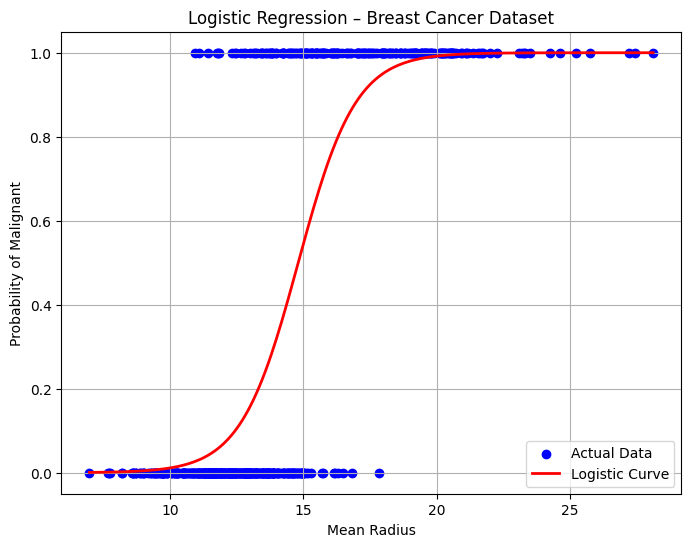

In [15]:
#Visualization (Using One Feature) 
#For visualization, we use mean radius. 
X_feature = data[['radius_mean']] 
y = data['diagnosis'] 
 
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split( 
    X_feature, y, test_size=0.25, random_state=42 
) 
 
model_f = LogisticRegression() 
model_f.fit(X_train_f, y_train_f) 
 
X_range = np.linspace(X_feature.min(), X_feature.max(), 200).reshape(-1,1) 
y_prob = model_f.predict_proba(X_range)[:,1] 
 
plt.figure(figsize=(8,6)) 
plt.scatter(X_feature, y, color='blue', label='Actual Data') 
plt.plot(X_range, y_prob, color='red', linewidth=2, label='Logistic Curve') 
plt.xlabel("Mean Radius") 
plt.ylabel("Probability of Malignant") 
plt.title("Logistic Regression – Breast Cancer Dataset") 
plt.legend() 
plt.grid(True) 
plt.show()